# 1. Install requirements

In [ ]:
!pip install onnxruntime-gpu opencv-python numpy matplotlib

# 2. Download weights

In [ ]:
!wget https://huggingface.co/maelic/REACTPlusPlus_PSG/resolve/main/yolo12m/react_pp_yolo12m.onnx?download=true -O react_psg_yolo12m.onnx

# !wget https://huggingface.co/maelic/REACTPlusPlus_IndoorVG/resolve/main/yolov8m/model.onnx?download=true -O react_indoorvg_yolov8m.onnx
# !wget https://huggingface.co/maelic/REACTPlusPlus_VG150/resolve/main/yolo12m/model.onnx?download=true -O react_vg150_yolo12m.onnx


# 3. Run inference

In [5]:
import cv2
import numpy as np
import onnxruntime as ort

from standalone_onnx_demo import SGG_ONNX_Standalone

# load with cv2
image = "364707036_0c24547f1f_z.jpg"
img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# initialize the model
model_path = "react_psg_yolo12m.onnx"
model = SGG_ONNX_Standalone(model_path, provider="CPUExecutionProvider")

# run inference
predictions = model.predict(img)

# print the predictions, predictions[0] = bounding boxes, predictions[1] = rel labels, predictions[2] = full rels string, predictions[3] = visualized image

for i, pred in enumerate(predictions[2]):
    print(pred)

for i, pred in enumerate(predictions[0]):
    print(pred)

[cuda preload] Loaded 61 CUDA libs from venv.
[cuda preload] Could not load 2 libs (may be normal): libfreetype-d2d71ad9.so.6.20.6, libharfbuzz-ef65cc8a.so.0.61321.0
Loading ONNX model from react_psg_yolo12m.onnx with CPUExecutionProvider...
Active providers: ['CPUExecutionProvider']
Loaded 133 object classes and 57 relation classes from metadata.
2_bicycle - driving on - 9_road: (triplet_score=0.73, rel_score=0.59)
1_bicycle - driving on - 9_road: (triplet_score=0.66, rel_score=0.44)
4_person - riding - 2_bicycle: (triplet_score=0.62, rel_score=0.34)
8_motorcycle - driving on - 9_road: (triplet_score=0.53, rel_score=0.25)
7_bicycle - driving on - 9_road: (triplet_score=0.52, rel_score=0.24)
5_person - riding - 8_motorcycle: (triplet_score=0.50, rel_score=0.19)
4_person - riding - 1_bicycle: (triplet_score=0.45, rel_score=0.13)
17_motorcycle - driving on - 9_road: (triplet_score=0.43, rel_score=0.24)
12_person - riding - 17_motorcycle: (triplet_score=0.32, rel_score=0.11)
4_person - cr

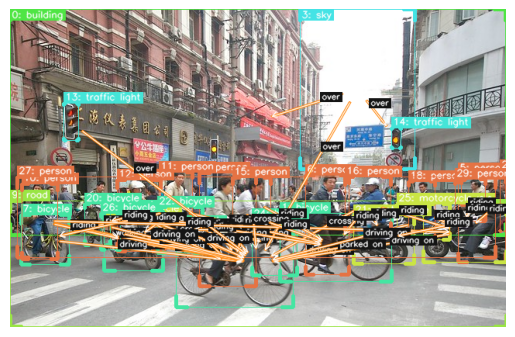

In [4]:
# visualize the cv2 image on the notebook
import matplotlib.pyplot as plt
plt.imshow(predictions[3])
plt.axis('off')
plt.show()